# 01 · ETH/UCY 탐색적 데이터 분석

Social-STGCNN 재현에 쓰는 ETH/UCY 보행자 궤적(2.5 fps, 미터 단위)을 살펴본다.
질문은 세 가지다.

1. 분할마다 장면·보행자 수와 장면 크기(N)가 얼마나 다른가 — 학습/테스트 난이도의 차이를 설명한다.
2. 보행자는 얼마나 빠르고, 얼마나 직선으로 걷는가 — 등속 모델(CVM)이 강한 이유.
3. 관측 8프레임(3.2 s)으로 12프레임(4.8 s)을 예측할 때 "평균 이동 거리"는 얼마인가 — ADE/FDE 의 스케일 감각.

데이터는 `foresight prepare` 가 만든 `data/processed/ethucy/<split>/<subset>.parquet` (long 포맷: scene, agent, t, x, y) 를 Polars/DuckDB 로 읽는다.

In [1]:
import os, json
from pathlib import Path
import numpy as np, polars as pl, duckdb
import matplotlib.pyplot as plt
ROOT = Path(os.environ.get("FORESIGHT_ROOT", ".")).resolve()
PROC = ROOT / "data/processed/ethucy"
SPLITS = ["eth", "hotel", "univ", "zara1", "zara2"]
plt.rcParams["figure.dpi"] = 110

## 1. 분할별 규모 — 장면 수, 보행자 수, 장면 크기

In [2]:
rows = []
for s in SPLITS:
    for sub in ["train", "val", "test"]:
        df = pl.read_parquet(PROC / s / f"{sub}.parquet")
        per_scene = df.group_by("scene").agg(pl.col("agent").n_unique().alias("n"))
        rows.append({"split": s, "subset": sub, "scenes": per_scene.height, "agents": df["agent"].n_unique(),
                     "N_mean": round(per_scene["n"].mean(), 1), "N_median": per_scene["n"].median(), "N_max": per_scene["n"].max()})
summary = pl.DataFrame(rows)
summary

split,subset,scenes,agents,N_mean,N_median,N_max
str,str,i64,i64,f64,f64,i64
"""eth""","""train""",2785,29809,10.7,5.0,57
"""eth""","""val""",660,5349,8.1,6.0,42
"""eth""","""test""",70,181,2.6,2.0,5
"""hotel""","""train""",2594,29152,11.2,6.0,57
"""hotel""","""val""",621,5136,8.3,6.0,42
…,…,…,…,…,…,…
"""zara1""","""val""",605,5118,8.5,6.0,42
"""zara1""","""test""",602,2253,3.7,3.0,14
"""zara2""","""train""",2112,25507,12.1,4.0,57


ETH 테스트는 **70 장면 / 181 보행자**로 매우 작다 — ADE 가 시드에 따라 흔들리는 이유이고, 논문·재현 수치의 분산이 가장 큰 분할이다.
UNIV 테스트는 반대로 장면당 평균 25명이 넘는 혼잡한 장면이다 (그래프가 크다).

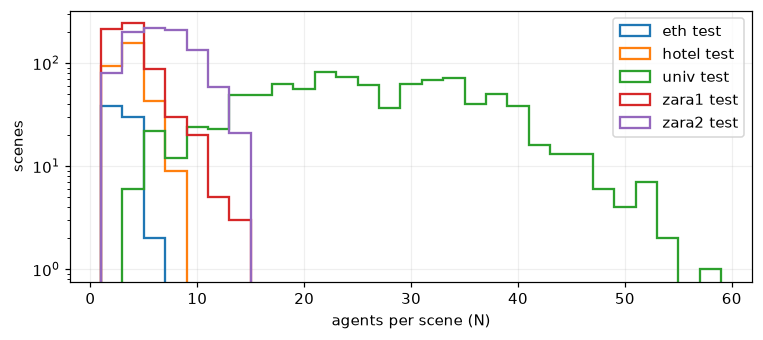

In [3]:
fig, ax = plt.subplots(figsize=(8, 3.2))
for s in SPLITS:
    df = pl.read_parquet(PROC / s / "test.parquet")
    n = df.group_by("scene").agg(pl.col("agent").n_unique().alias("n"))["n"].to_numpy()
    ax.hist(n, bins=np.arange(1, 60, 2), histtype="step", label=f"{s} test", lw=1.5)
ax.set_xlabel("agents per scene (N)"); ax.set_ylabel("scenes"); ax.set_yscale("log"); ax.legend(); ax.grid(alpha=.2)
plt.show()

## 2. 속력과 직선성 — 왜 등속 모델이 강한가

In [4]:
con = duckdb.connect()
stats = []
for s in SPLITS:
    path = str(PROC / s / "test.parquet")
    q = f'''
    WITH d AS (
      SELECT scene, agent, t, x, y,
             x - lag(x) OVER (PARTITION BY scene, agent ORDER BY t) AS dx,
             y - lag(y) OVER (PARTITION BY scene, agent ORDER BY t) AS dy
      FROM read_parquet('{path}')
    )
    SELECT '{s}' AS split,
           avg(sqrt(dx*dx+dy*dy))/0.4 AS speed_mean_mps,
           quantile_cont(sqrt(dx*dx+dy*dy)/0.4, 0.5) AS speed_median_mps,
           avg(CASE WHEN sqrt(dx*dx+dy*dy)/0.4 < 0.1 THEN 1 ELSE 0 END) AS frac_standing
    FROM d WHERE dx IS NOT NULL'''
    stats.append(con.execute(q).fetchdf())
import pandas as pd
pd.concat(stats).round(3)

,split,speed_mean_mps,speed_median_mps,frac_standing
0,eth,1.150,1.150,0.226
0,hotel,0.469,0.150,0.463
0,univ,0.539,0.523,0.211
0,zara1,0.972,1.070,0.057
0,zara2,0.542,0.172,0.483


In [5]:
# 직선성: 예측 구간(12 프레임)을 2차 다항식으로 맞췄을 때의 잔차 (Social-GAN 의 non-linear 판정 방식, 임계 0.002)
def nonlinear_fraction(split, subset="test", threshold=0.002):
    df = pl.read_parquet(PROC / split / f"{subset}.parquet").filter(pl.col("t") >= 8)
    frac = []
    for (_, _), g in df.group_by(["scene", "agent"], maintain_order=True):
        t = np.arange(12); res = 0.0
        for c in ("x", "y"):
            res += np.polyfit(t, g[c].to_numpy(), 2, full=True)[1].sum()
        frac.append(res >= threshold)
    return float(np.mean(frac))
pl.DataFrame({"split": SPLITS, "nonlinear_frac_test": [round(nonlinear_fraction(s), 3) for s in SPLITS]})

split,nonlinear_frac_test
str,f64
"""eth""",0.912
"""hotel""",0.777
"""univ""",0.823
"""zara1""",0.889
"""zara2""",0.529


Social-GAN 의 임계값(잔차 합 0.002)은 매우 엄격해서 테스트 보행자의 **53~91%** 가 "비선형"으로 분류된다.
그런데도 등속 모델(CVM)이 ADE 0.5~1.0 m 를 내는 이유는 잔차의 **절대 크기**가 작기 때문이다 — 4.8 초 이동 거리(아래) 대비 몇 % 수준의 굴곡이다.
hotel/zara2 는 서 있는(속력 < 0.1 m/s) 보행자가 46~48% 로 많아 정지 예측이 쉬운 반면, eth/zara1 은 평균 1 m/s 이상으로 빠르다.

## 3. 예측 구간의 이동 거리 — ADE/FDE 스케일

In [6]:
rows = []
for s in SPLITS:
    df = pl.read_parquet(PROC / s / "test.parquet")
    last_obs = df.filter(pl.col("t") == 7).select("scene", "agent", pl.col("x").alias("x0"), pl.col("y").alias("y0"))
    fut = df.filter(pl.col("t") == 19).join(last_obs, on=["scene", "agent"])
    disp = ((fut["x"] - fut["x0"])**2 + (fut["y"] - fut["y0"])**2).sqrt()
    rows.append({"split": s, "displacement_4.8s_mean_m": round(disp.mean(), 2), "displacement_4.8s_p90_m": round(disp.quantile(0.9), 2)})
pl.DataFrame(rows)

split,displacement_4.8s_mean_m,displacement_4.8s_p90_m
str,f64,f64
"""eth""",4.82,10.74
"""hotel""",2.09,6.67
"""univ""",2.47,4.89
"""zara1""",4.61,6.33
"""zara2""",2.53,6.09


4.8 초 동안 평균 4~6 m 를 이동한다. 논문의 FDE 0.5~1.1 m 는 이동 거리의 10~25% 오차라는 뜻이다.
"아무것도 안 움직인다"고 예측하면 FDE ≈ 이동 거리가 되므로, 지표를 읽을 때 이 스케일을 기준으로 삼는다.

## 4. 장면 예시

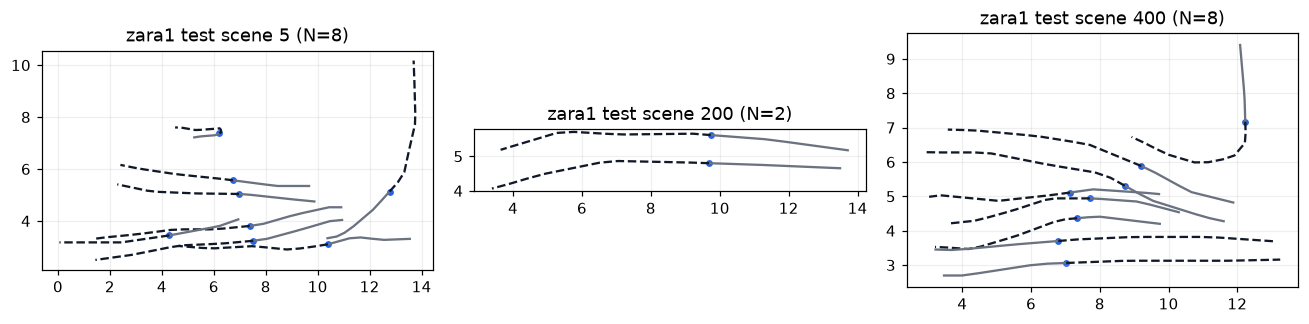

In [7]:
from foresight.data.ethucy import SceneSet
ss = SceneSet.load(PROC / "zara1" / "test.npz")
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, i in zip(axes, [5, 200, 400]):
    pos = ss.scene(i)
    for a in range(pos.shape[0]):
        ax.plot(pos[a, :8, 0], pos[a, :8, 1], color="#6b7280"); ax.plot(pos[a, 7:, 0], pos[a, 7:, 1], color="#111827", ls="--")
        ax.scatter(pos[a, 7, 0], pos[a, 7, 1], s=12, color="#2563eb")
    ax.set_title(f"zara1 test scene {i} (N={pos.shape[0]})"); ax.set_aspect("equal"); ax.grid(alpha=.2)
plt.tight_layout(); plt.show()

## 정리
- 분할 간 규모 차이가 크다: ETH 테스트(181명)는 통계적으로 불안정, UNIV 테스트는 혼잡(N 최대 57).
- 속력·정지 비율이 분할마다 크게 다르다(hotel/zara2 는 절반 가까이 정지). 분할별 ADE 를 한 줄 평균으로만 읽으면 안 되는 이유다.
- 4.8 s 에 평균 2~5 m 이동 → 논문의 FDE 0.5~1.1 m 는 이동 거리의 10~25%. CVM 이 강한 기준선이고, 모델의 가치는 회피·회전 구간과 **불확실성(분포)** 에 있다.
- 이 관찰이 평가 설계(`docs/evaluation_methodology.md`)와 충돌 위험 점수(분포 기반)의 근거다.